# Partie 1 : Analyse et Préparation des Données

## Objectif : 
- Analyser et préparer les données des assurés pour garantir qu'elles sont propres, cohérentes et prêtes pour l'entraînement du modèle.

## Tâche 1 : Chargement des données
- Importer les données à l'aide de la bibliothèque Pandas.
- Vérifier le type et la structure des colonnes.


In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("assurance-maladie.csv")

In [2]:
df.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [3]:
df.shape

(1338, 7)

## Tâche 2 : Analyse exploratoire des données (EDA)
- Comprendre la structure générale du jeu de données (types de données, dimensions, aperçus).

In [4]:
df.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [5]:
df.shape

(1338, 7)

In [6]:
df.info

<bound method DataFrame.info of       age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500
1337   61  female  29.070         0    yes  northwest  29141.36030

[1338 rows x 7 columns]>

In [7]:
df.describe

<bound method NDFrame.describe of       age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500
1337   61  female  29.070         0    yes  northwest  29141.36030

[1338 rows x 7 columns]>

In [8]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


- Effectuer une analyse descriptive des données (moyennes, médianes, écarts-types pour les variables numériques ; fréquences pour les catégoriques).

In [9]:
num_cols = df.select_dtypes(include='number')

print("Moyennes :\n",   num_cols.mean())

Moyennes :
 age            39.207025
bmi            30.663397
children        1.094918
charges     13270.422265
dtype: float64


In [10]:
print("Médianes :\n",   num_cols.median())

Médianes :
 age           39.000
bmi           30.400
children       1.000
charges     9382.033
dtype: float64


In [11]:
print("Ecarts-types :\n",  num_cols.std())

Ecarts-types :
 age            14.049960
bmi             6.098187
children        1.205493
charges     12110.011237
dtype: float64


In [12]:
print("le coefficient d’asymétrie skewness")
num_cols.skew()


le coefficient d’asymétrie skewness


age         0.055673
bmi         0.284047
children    0.938380
charges     1.515880
dtype: float64

### fréquences pour les catégoriques

In [13]:
cat_cols = df.select_dtypes(include='object')

for col in cat_cols.columns:
    print("\n", col)
    print(df[col].value_counts())


 sex
sex
male      676
female    662
Name: count, dtype: int64

 smoker
smoker
no     1064
yes     274
Name: count, dtype: int64

 region
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


C:\Users\xFawzer\AppData\Local\Temp\ipykernel_28372\3000948779.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object')


### Identifier les valeurs manquantes.

In [14]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

- Pourcentage des valeurs manquantes (juste pour moi)

In [15]:
missing_pourcentage = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_pourcentage

age         0.0
sex         0.0
bmi         0.0
children    0.0
smoker      0.0
region      0.0
charges     0.0
dtype: float64

- Visualiser les manquants avec une heatmap : (juste pour moi)

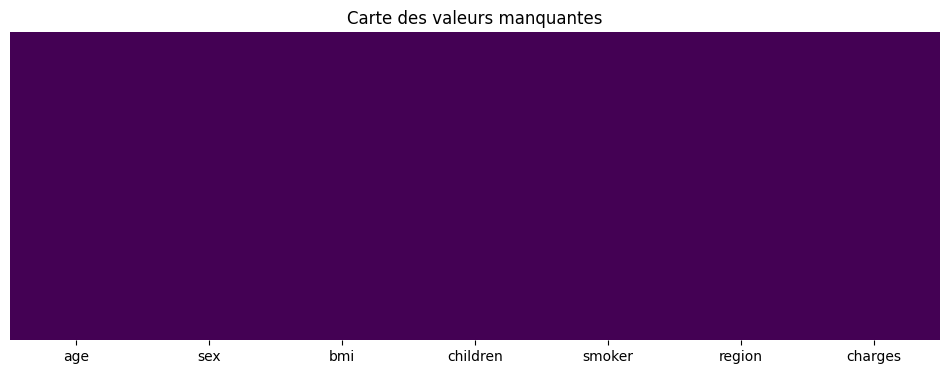

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Carte des valeurs manquantes")
plt.show()

- les doublons

In [17]:
print("Nomdes des doublons", df.duplicated().sum())

print("\n\nla ligne dupliquée ", df[df.duplicated()])

print("\nles deux lignes\n", df[df.duplicated(keep=False)])

Nomdes des doublons 1


la ligne dupliquée       age   sex    bmi  children smoker     region    charges
581   19  male  30.59         0     no  northwest  1639.5631

les deux lignes
      age   sex    bmi  children smoker     region    charges
195   19  male  30.59         0     no  northwest  1639.5631
581   19  male  30.59         0     no  northwest  1639.5631


- Analyser la distribution des variables numériques (ex. : histogrammes avec Matplotlib/Seaborn).

In [18]:
num_cols

,age,bmi,children,charges
0,19,27.900,0,16884.92400
1,18,33.770,1,1725.55230
2,28,33.000,3,4449.46200
3,33,22.705,0,21984.47061
4,32,28.880,0,3866.85520
...,...,...,...,...
1333,50,30.970,3,10600.54830
1334,18,31.920,0,2205.98080
1335,18,36.850,0,1629.83350
1336,21,25.800,0,2007.94500


### histograme pour l'age

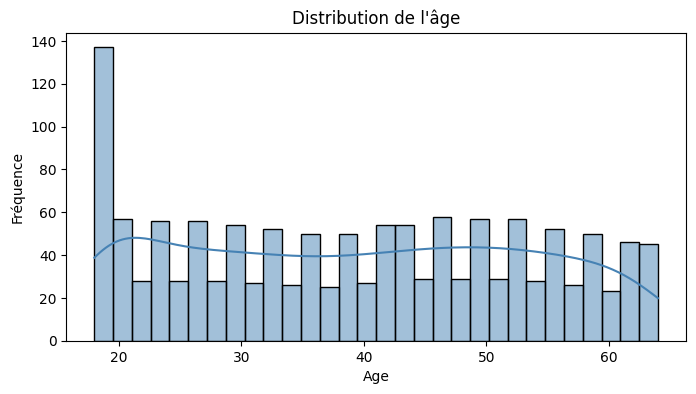

In [19]:
plt.figure(figsize=(8, 4)) # la taille
sns.histplot(df['age'], bins=30, kde=True, color='steelblue')
plt.title("Distribution de l'âge")
plt.xlabel("Age")
plt.ylabel("Fréquence")
plt.show()

### Histogramme de la variable bmi

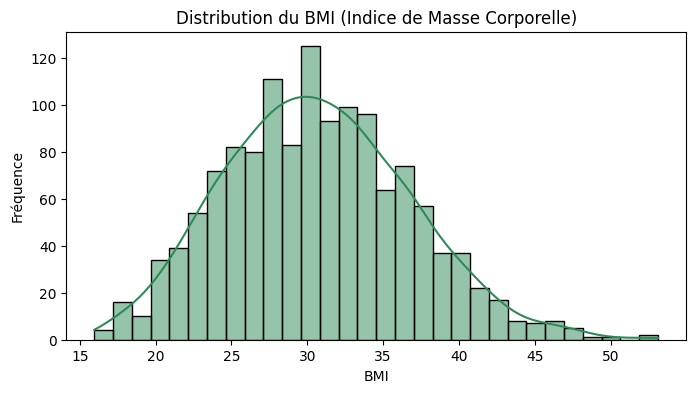

In [20]:
plt.figure(figsize=(8, 4))
sns.histplot(df['bmi'], bins=30, kde=True, color='seagreen')
plt.title("Distribution du BMI (Indice de Masse Corporelle)")
plt.xlabel("BMI")
plt.ylabel("Fréquence")
plt.show()

### Histogramme de la variable children

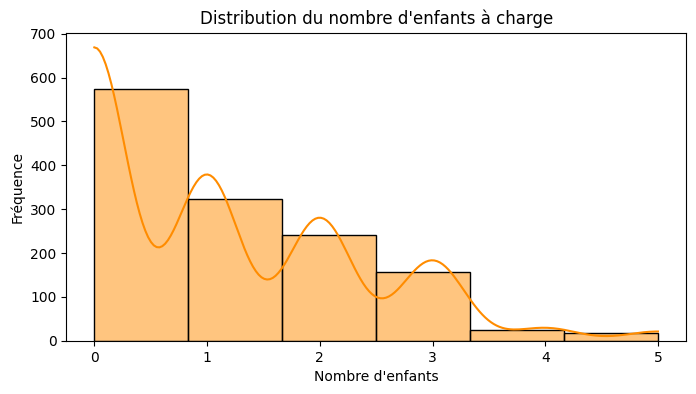

In [21]:
plt.figure(figsize=(8, 4))
sns.histplot(df['children'], bins=6, kde=True, color='darkorange')
plt.title("Distribution du nombre d'enfants à charge")
plt.xlabel("Nombre d'enfants")
plt.ylabel("Fréquence")
plt.show()

### Histogramme de la variable charges

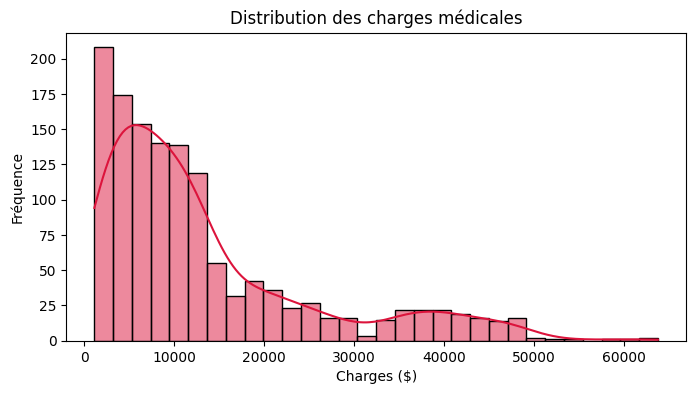

In [22]:
plt.figure(figsize=(8, 4))
sns.histplot(df['charges'], bins=30, kde=True, color='crimson')
plt.title("Distribution des charges médicales")
plt.xlabel("Charges ($)")
plt.ylabel("Fréquence")
plt.show()

### Boxplots de toutes les variables

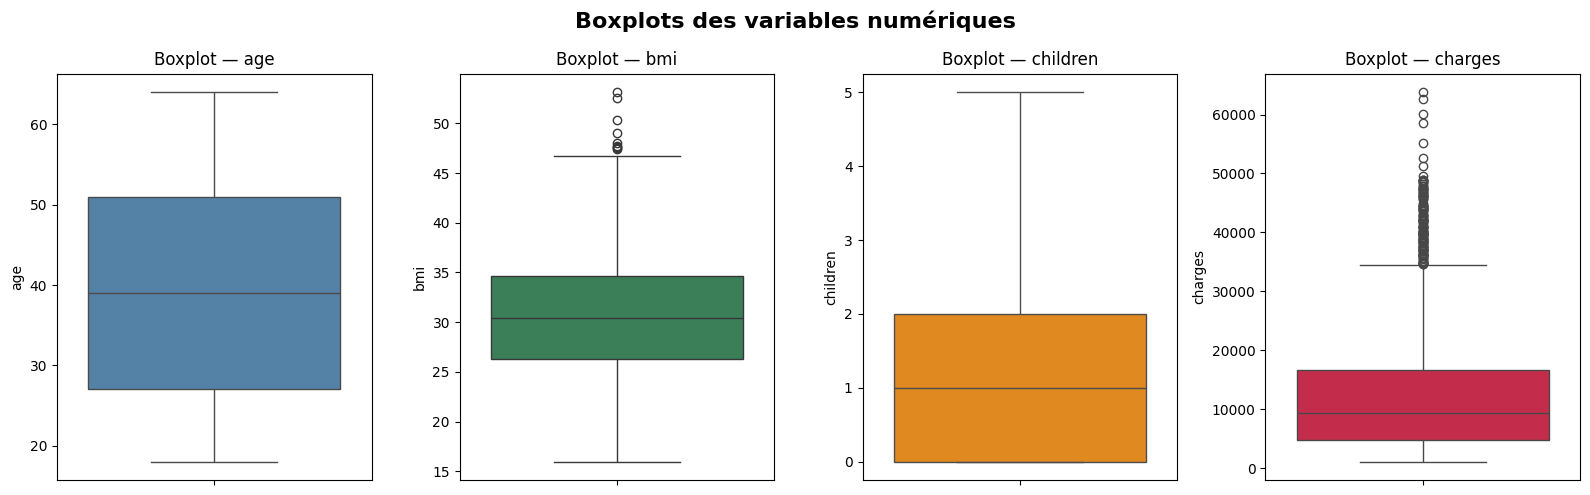

In [23]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

couleurs = ['steelblue', 'seagreen', 'darkorange', 'crimson']

for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i], color=couleurs[i])
    axes[i].set_title(f"Boxplot — {col}")

plt.suptitle("Boxplots des variables numériques",
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Tableau de Skewness

In [24]:
print("SKEWNESS (asymétrie) des variables numériques :")
print("─" * 50)

for col in num_cols:
    skew = df[col].skew()
    if abs(skew) < 0.5:
        interpretation = "Normale"
    elif abs(skew) < 1:
        interpretation = "Légèrement asymétrique"
    else:
        interpretation = "Très asymétrique → transformer"
    print(f"  {col:<12} skew = {skew:+.2f}   {interpretation}")

SKEWNESS (asymétrie) des variables numériques :
──────────────────────────────────────────────────
  age          skew = +0.06   Normale
  bmi          skew = +0.28   Normale
  children     skew = +0.94   Légèrement asymétrique
  charges      skew = +1.52   Très asymétrique → transformer


### resumé

In [25]:
print("RÉSUMÉ — ANALYSE DE DISTRIBUTION")

for col in num_cols:
    print(f"""
  Variable  : {col}
  Moyenne   : {df[col].mean():.2f}
  Médiane   : {df[col].median():.2f}
  Écart-type: {df[col].std():.2f}
  Skewness  : {df[col].skew():.2f}
  Min       : {df[col].min():.2f}
  Max       : {df[col].max():.2f}
""")

RÉSUMÉ — ANALYSE DE DISTRIBUTION

  Variable  : age
  Moyenne   : 39.21
  Médiane   : 39.00
  Écart-type: 14.05
  Skewness  : 0.06
  Min       : 18.00
  Max       : 64.00


  Variable  : bmi
  Moyenne   : 30.66
  Médiane   : 30.40
  Écart-type: 6.10
  Skewness  : 0.28
  Min       : 15.96
  Max       : 53.13


  Variable  : children
  Moyenne   : 1.09
  Médiane   : 1.00
  Écart-type: 1.21
  Skewness  : 0.94
  Min       : 0.00
  Max       : 5.00


  Variable  : charges
  Moyenne   : 13270.42
  Médiane   : 9382.03
  Écart-type: 12110.01
  Skewness  : 1.52
  Min       : 1121.87
  Max       : 63770.43



- Étudier les relations entre variables à l'aide de matrices de corrélation et de visualisations (ex. : pairplots ou heatmaps).

### Calculer la matrice de corrélation

In [26]:
matrice_corr = df[['age', 'bmi', 'children', 'charges']].corr()
print(matrice_corr)

               age       bmi  children   charges
age       1.000000  0.109272  0.042469  0.299008
bmi       0.109272  1.000000  0.012759  0.198341
children  0.042469  0.012759  1.000000  0.067998
charges   0.299008  0.198341  0.067998  1.000000


### Visualiser la Heatmap

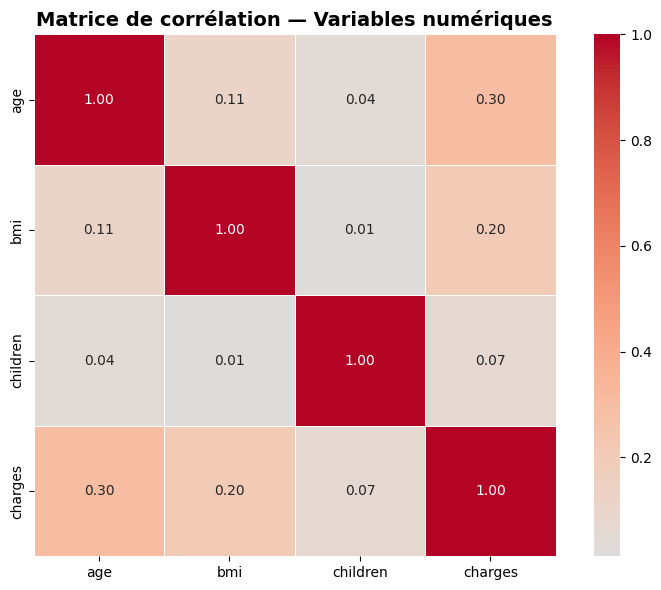

In [27]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    matrice_corr,
    annot=True, 
    fmt='.2f', 
    cmap='coolwarm', 
    center=0,
    linewidths=0.5, 
    square=True 
)

plt.title("Matrice de corrélation — Variables numériques",
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Pairplot

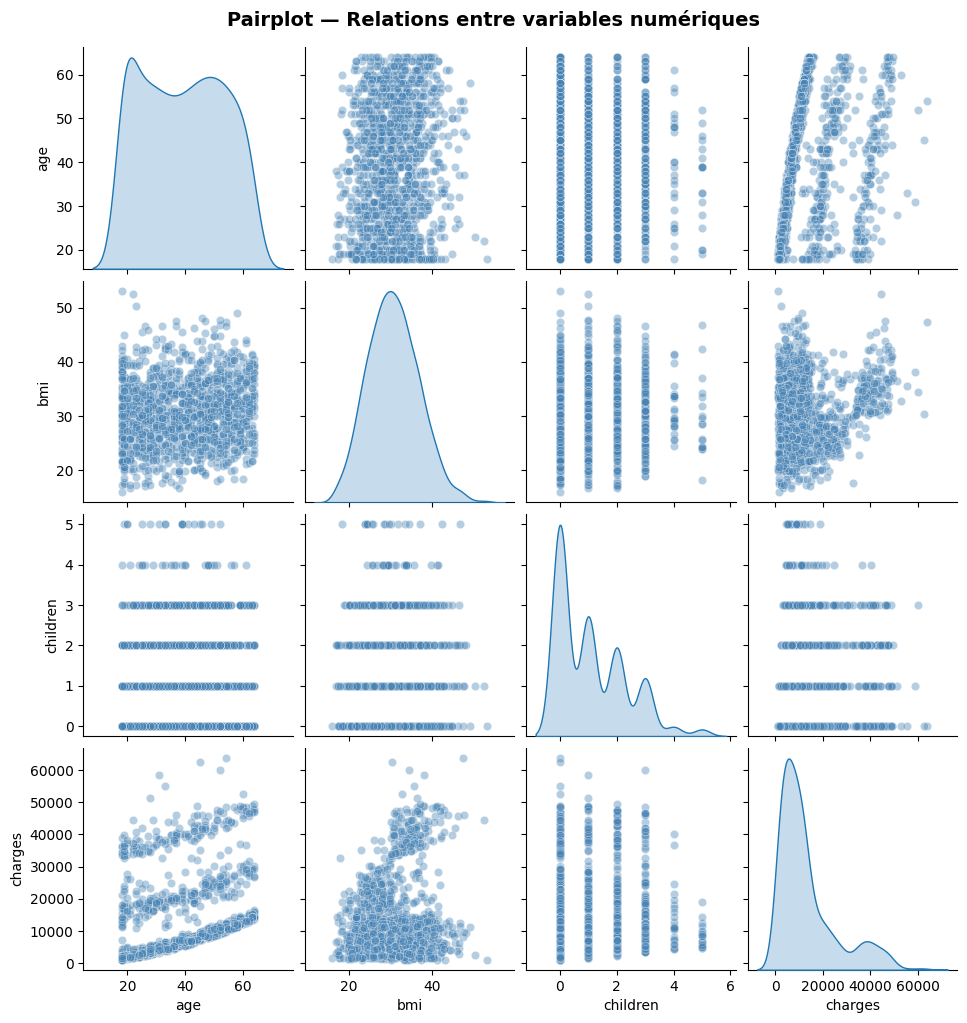

In [28]:
sns.pairplot(
    df[['age', 'bmi', 'children', 'charges']],
    diag_kind='kde', 
    plot_kws={'alpha': 0.4, 'color': 'steelblue'}
)

plt.suptitle("Pairplot — Relations entre variables numériques",
             fontsize=14, fontweight='bold', y=1.02)
plt.show()

### Pairplot coloré par smoker

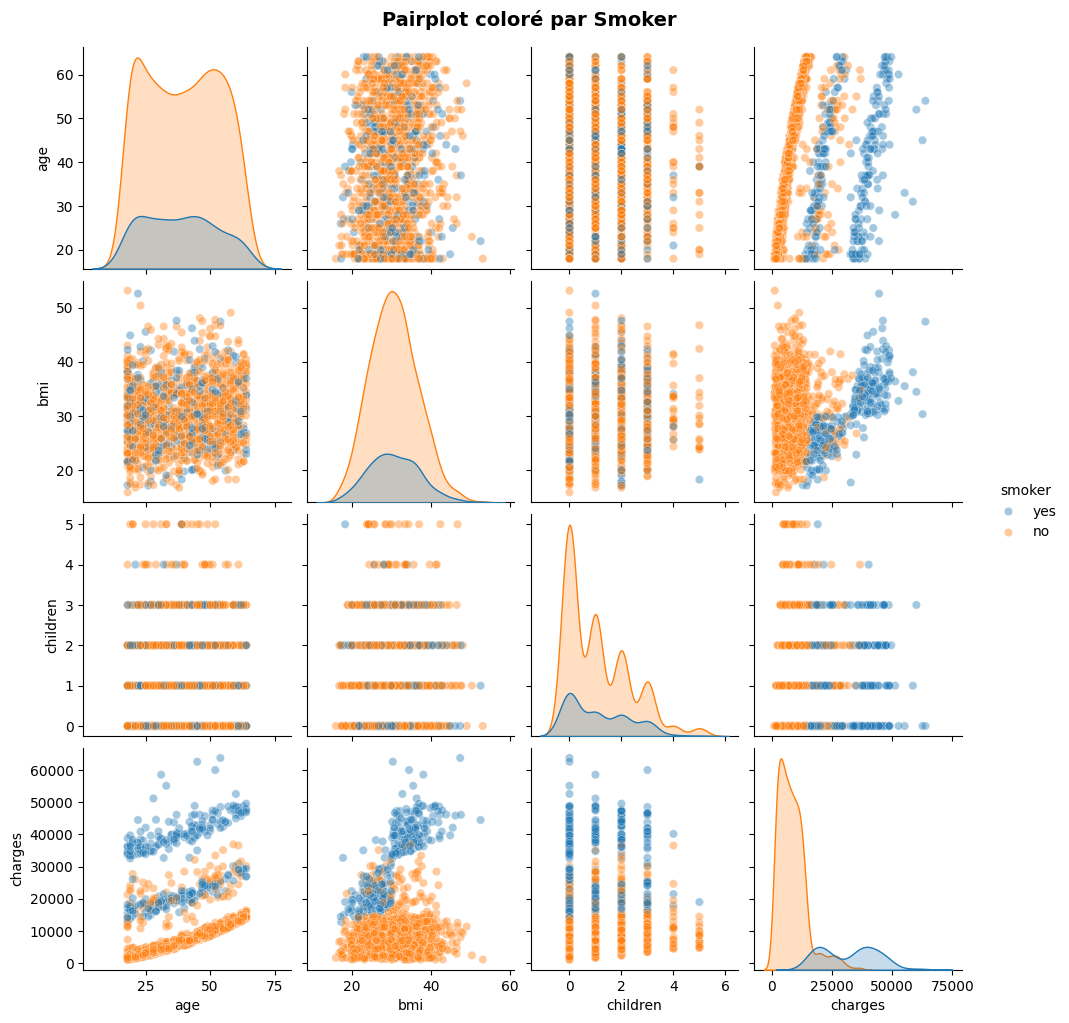

In [29]:
sns.pairplot(
    df[['age', 'bmi', 'children', 'charges', 'smoker']],
    hue='smoker',         # colorier par fumeur/non-fumeur
    diag_kind='kde',
    plot_kws={'alpha': 0.4}
)

plt.suptitle("Pairplot coloré par Smoker",
             fontsize=14, fontweight='bold', y=1.02)
plt.show()

###  Conclusion de l'analyse des relations

In [30]:

print("CORRÉLATIONS AVEC LA VARIABLE CIBLE (charges) :")

corr_charges = df[['age', 'bmi', 'children', 'charges']]\
               .corr()['charges']\
               .drop('charges')\
               .sort_values(ascending=False)

for col, val in corr_charges.items():
    if abs(val) >= 0.3:
        niveau = "Forte"
    elif abs(val) >= 0.1:
        niveau = "Modérée"
    else:
        niveau = "Faible"
    print(f"  {col:<12} : {val:+.3f}   {niveau}")

CORRÉLATIONS AVEC LA VARIABLE CIBLE (charges) :
  age          : +0.299   Modérée
  bmi          : +0.198   Modérée
  children     : +0.068   Faible


## Tâche 3 : Prétraitement des données
- Gestion des valeurs manquantes (ex. : imputation).
- Suppression des doublons.
- Détection et gestion des valeurs aberrantes : Utiliser des techniques statistiques (ex. : boîte à moustaches avec Seaborn, z-score > 3, ou IQR pour identifier les outliers) et gérer les lignes contenant des valeurs aberrantes.
- Encoder les variables catégoriques (sexe, smoker, région) (ex: one-hot encoding ou label encoding).
- Diviser les données en ensembles d'entraînement et de test (80% / 20%) avec traintestsplit de Scikit-learn.
- Appliquer une normalisation (MinMaxScaler) ou une standardisation (StandardScaler) sur les variables numériques pour harmoniser les échelles.


In [31]:
df.isnull().sum().sum()

np.int64(0)

In [32]:
# suppression des doublons

nb_doublons = df.duplicated().sum()
nb_doublons

np.int64(1)

In [33]:
df = df.drop_duplicates()
nb_doublons = df.duplicated().sum()
nb_doublons

np.int64(0)

Pour ce projet on utilise IQR car charges est asymétrique — le Z-Score suppose une distribution normale.

### Visualiser les outliers avec Boxplot

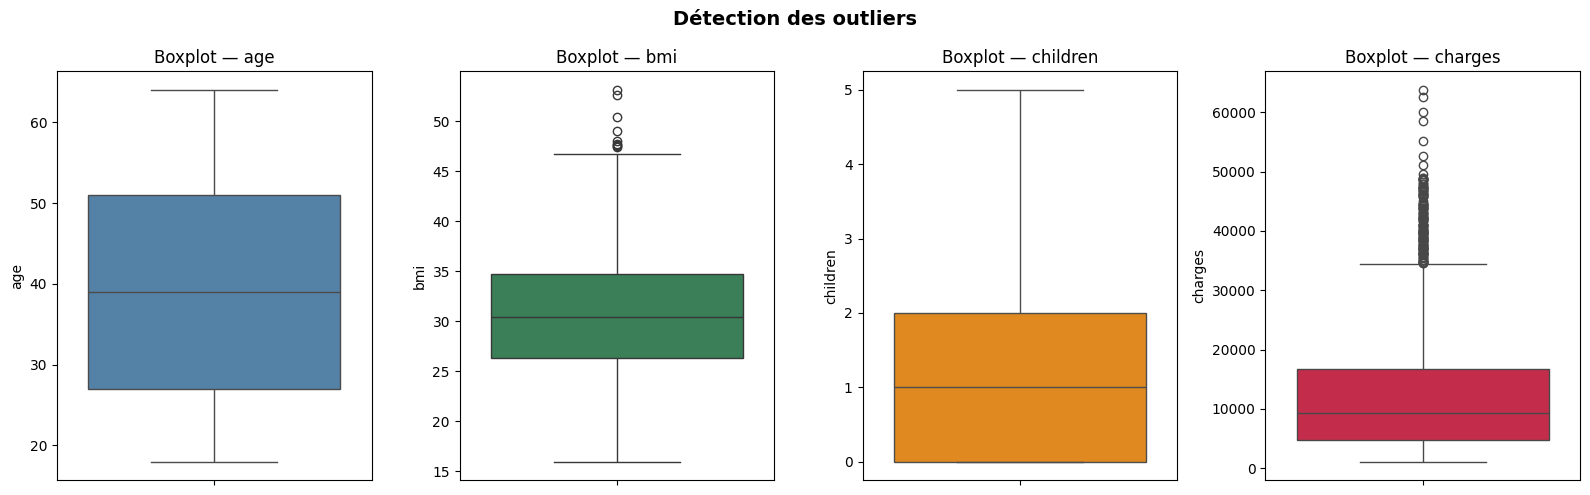

In [34]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
couleurs = ['steelblue', 'seagreen', 'darkorange', 'crimson']

for i, col in enumerate(['age', 'bmi', 'children', 'charges']):
    sns.boxplot(y=df[col], ax=axes[i], color=couleurs[i])
    axes[i].set_title(f"Boxplot — {col}")

plt.suptitle("Détection des outliers", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Détecter les outliers avec IQR

In [35]:
print("DÉTECTION DES OUTLIERS — MÉTHODE IQR")

outliers_info = {}

for col in num_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_basse = Q1 - 1.5 * IQR
    limite_haute = Q3 + 1.5 * IQR

    outliers = df[(df[col] < limite_basse) | (df[col] > limite_haute)]
    outliers_info[col] = outliers.index

    print(f"\n  {col} :")
    print(f"    Q1 = {Q1:.2f}  |  Q3 = {Q3:.2f}  |  IQR = {IQR:.2f}")
    print(f"    Limite basse = {limite_basse:.2f}")
    print(f"    Limite haute = {limite_haute:.2f}")
    print(f"    Outliers détectés : {len(outliers)}")

DÉTECTION DES OUTLIERS — MÉTHODE IQR

  age :
    Q1 = 27.00  |  Q3 = 51.00  |  IQR = 24.00
    Limite basse = -9.00
    Limite haute = 87.00
    Outliers détectés : 0

  bmi :
    Q1 = 26.29  |  Q3 = 34.70  |  IQR = 8.41
    Limite basse = 13.67
    Limite haute = 47.32
    Outliers détectés : 9

  children :
    Q1 = 0.00  |  Q3 = 2.00  |  IQR = 2.00
    Limite basse = -3.00
    Limite haute = 5.00
    Outliers détectés : 0

  charges :
    Q1 = 4746.34  |  Q3 = 16657.72  |  IQR = 11911.37
    Limite basse = -13120.72
    Limite haute = 34524.78
    Outliers détectés : 139


### Supprimer les outliers

In [36]:
all_outliers = set()
for col in num_cols:
    all_outliers.update(outliers_info[col])

print(f"Lignes avant suppression  : {df.shape[0]}")
print(f"Total outliers détectés   : {len(all_outliers)}")

df = df.drop(index=all_outliers)
df = df.reset_index(drop=True) 

print(f"Lignes après suppression  : {df.shape[0]}")

Lignes avant suppression  : 1337
Total outliers détectés   : 145
Lignes après suppression  : 1192


### Label Encoding sur sex et smoker

In [37]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Encoder sex : female=0, male=1
df['sex']    = le.fit_transform(df['sex'])

# Encoder smoker : no=0, yes=1
df['smoker'] = le.fit_transform(df['smoker'])

print("Encodage Label — sex et smoker :")
print(df[['sex', 'smoker']].value_counts())

Encodage Label — sex et smoker :
sex  smoker
0    0         543
1    0         511
     1          70
0    1          68
Name: count, dtype: int64


### One-Hot Encoding sur region

In [38]:
df = pd.get_dummies(df, columns=['region'], drop_first=True)

print("\nColonnes après One-Hot Encoding :")
print(df.columns.tolist())
print(f"\nDimensions : {df.shape}")


Colonnes après One-Hot Encoding :
['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'region_northwest', 'region_southeast', 'region_southwest']

Dimensions : (1192, 9)


### Diviser les données en ensembles d'entraînement et de test (80% / 20%) avec traintestsplit de Scikit-learn.


In [39]:
from sklearn.model_selection import train_test_split

# Séparer features (X) et cible (y)
X = df.drop(columns=['charges'])
y = df['charges']

# Split 80% train / 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("SPLIT TRAIN / TEST :")
print("─" * 40)
print(f"Dataset total  : {df.shape[0]} lignes")
print(f"X_train        : {X_train.shape}")
print(f"X_test         : {X_test.shape}")
print(f"y_train        : {y_train.shape}")
print(f"y_test         : {y_test.shape}")

SPLIT TRAIN / TEST :
────────────────────────────────────────
Dataset total  : 1192 lignes
X_train        : (953, 8)
X_test         : (239, 8)
y_train        : (953,)
y_test         : (239,)


### Normalisation / Standardisation

In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
  
  
# Colonnes numériques à scaler
cols_a_scaler = ['age', 'bmi', 'children']

scaler.fit(X_train[cols_a_scaler])

X_train[cols_a_scaler] = scaler.transform(X_train[cols_a_scaler])
X_test[cols_a_scaler]  = scaler.transform(X_test[cols_a_scaler])

print("STANDARDISATION :")
print("─" * 40)
print("Avant scaling — moyenne de age dans X_train :")
print(f"  moyenne = {X_train['age'].mean():.4f}  (≈ 0)")
print(f"  std     = {X_train['age'].std():.4f}   (≈ 1)")

STANDARDISATION :
────────────────────────────────────────
Avant scaling — moyenne de age dans X_train :
  moyenne = 0.0000  (≈ 0)
  std     = 1.0005   (≈ 1)
